# 02 · Magnitud de completitud del catálogo sísmico de Mendoza

Este notebook estima y valida la **magnitud de completitud (Mc)** del catálogo. Mc es la magnitud mínima por encima de la cual se supone que los eventos están registrados de manera suficientemente completa para un análisis estadístico.

Los sismos pequeños son más difíciles de detectar y su registro puede cambiar con la cobertura, sensibilidad y operación de la red. Si se comparan densidades espaciales sin controlar Mc, una zona o un período con mejor detección puede parecer artificialmente más activo. Por eso estimamos Mc antes de avanzar con comparaciones espaciales.

**Entrada inmutable:** `data/processed/catalogo_sismico_mendoza_v1.1_final.csv`  
**Subconjunto de trabajo:** únicamente filas con `mw_analysis_ready == "yes"`  
**Magnitud principal:** `mw_reference`

## 1. Carga y validación

El primer bloque localiza la raíz del proyecto, crea la carpeta de figuras y carga el CSV sin modificarlo. Luego convierte `time_utc`, aplica el filtro analítico solicitado y resume cobertura, faltantes y rango de magnitudes.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

BIN_WIDTH = 0.10
PERIODS = {
    "2000-2004": (2000, 2004),
    "2005-2009": (2005, 2009),
    "2010-2014": (2010, 2014),
    "2015-2019": (2015, 2019),
    "2020-2025": (2020, 2025),
}
MIN_TOTAL_RELIABLE = 100
MIN_ABOVE_MC_RELIABLE = 50


def find_project_root(start: Path) -> Path:
    # Encuentra la raíz para poder ejecutar desde el proyecto o desde notebooks/.
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "catalogo_sismico_mendoza_v1.1_final.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "mc"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Entrada: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Figuras: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Raíz del proyecto: C:\Users\Nicolas\Desktop\proyecto-sismico-mendoza
Entrada: data\processed\catalogo_sismico_mendoza_v1.1_final.csv
Figuras: outputs\mc


In [2]:
catalog = pd.read_csv(DATA_PATH, low_memory=False)
catalog["time_utc"] = pd.to_datetime(catalog["time_utc"], utc=True, errors="coerce")

required_columns = {"time_utc", "mw_analysis_ready", "mw_reference"}
missing_columns = required_columns.difference(catalog.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

analysis_catalog = catalog.loc[
    catalog["mw_analysis_ready"].astype("string").str.strip().str.lower().eq("yes")
].copy()
analysis_catalog["mw_reference"] = pd.to_numeric(
    analysis_catalog["mw_reference"], errors="coerce"
)

if analysis_catalog.empty:
    raise ValueError("El filtro mw_analysis_ready == 'yes' no devolvió eventos.")
if analysis_catalog["time_utc"].isna().any():
    warnings.warn("Hay fechas inválidas o faltantes en el subconjunto analítico.")

summary = pd.DataFrame(
    {
        "métrica": [
            "Filas del CSV",
            "Eventos analysis-ready",
            "Inicio temporal",
            "Fin temporal",
            "time_utc faltante",
            "mw_reference faltante",
            "Mw mínimo",
            "Mw máximo",
        ],
        "valor": [
            len(catalog),
            len(analysis_catalog),
            analysis_catalog["time_utc"].min(),
            analysis_catalog["time_utc"].max(),
            int(analysis_catalog["time_utc"].isna().sum()),
            int(analysis_catalog["mw_reference"].isna().sum()),
            analysis_catalog["mw_reference"].min(),
            analysis_catalog["mw_reference"].max(),
        ],
    }
)
display(summary)

,métrica,valor
0,Filas del CSV,4623
1,Eventos analysis-ready,4523
2,Inicio temporal,2000-01-04 15:10:56.560000+00:00
3,Fin temporal,2025-12-02 23:28:31.827000+00:00
4,time_utc faltante,0
5,mw_reference faltante,0
6,Mw mínimo,0.394
7,Mw máximo,5.700


In [3]:
magnitudes = analysis_catalog["mw_reference"].dropna().to_numpy(dtype=float)

validation = pd.DataFrame(
    {
        "control": [
            "Mw finito",
            "Fechas entre 2000 y 2025",
            "Filtro aplicado exclusivamente a 'yes'",
        ],
        "resultado": [
            bool(np.isfinite(magnitudes).all()),
            bool(analysis_catalog["time_utc"].dropna().dt.year.between(2000, 2025).all()),
            bool(
                analysis_catalog["mw_analysis_ready"]
                .astype("string")
                .str.strip()
                .str.lower()
                .eq("yes")
                .all()
            ),
        ],
    }
)
display(validation)

,control,resultado
0,Mw finito,True
1,Fechas entre 2000 y 2025,True
2,Filtro aplicado exclusivamente a 'yes',True


## 2. Distribución frecuencia–magnitud

La distribución **no acumulada** cuenta eventos por intervalo de magnitud; su máximo será la base de MAXC. La distribución **acumulada** cuenta `N(Mw ≥ m)` y permite ver el tramo que podría seguir una relación Gutenberg–Richter. Ambos gráficos son preparatorios: por sí solos no fijan un Mc definitivo.

In [4]:
def magnitude_distribution(values, bin_width=0.10):
    # Devuelve centros, bordes, frecuencia y frecuencia acumulada por encima.
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("Se necesitan magnitudes finitas.")
    if bin_width <= 0:
        raise ValueError("bin_width debe ser positivo.")

    first_center = np.floor(values.min() / bin_width) * bin_width
    last_center = np.ceil(values.max() / bin_width) * bin_width
    centers = np.arange(first_center, last_center + bin_width / 2, bin_width)
    centers = np.round(centers, 10)
    edges = np.concatenate(
        ([centers[0] - bin_width / 2], centers + bin_width / 2)
    )
    counts, _ = np.histogram(values, bins=edges)
    cumulative = counts[::-1].cumsum()[::-1]
    return pd.DataFrame(
        {"magnitude": centers, "frequency": counts, "cumulative": cumulative}
    )


fmd_full = magnitude_distribution(magnitudes, BIN_WIDTH)
display(fmd_full.head(10))

,magnitude,frequency,cumulative
0,0.300,0,4523
1,0.400,2,4523
2,0.500,1,4521
3,0.600,1,4520
4,0.700,8,4519
5,0.800,5,4511
6,0.900,10,4506
7,1.000,15,4496
8,1.100,14,4481
9,1.200,27,4467


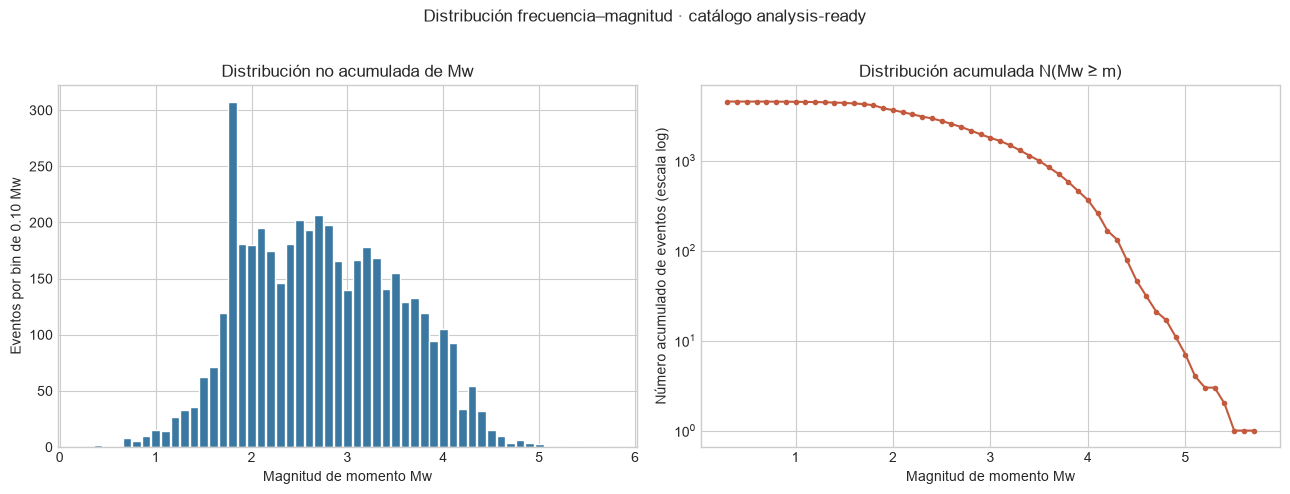

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(
    fmd_full["magnitude"],
    fmd_full["frequency"],
    width=BIN_WIDTH * 0.9,
    color="#3A78A1",
    edgecolor="white",
)
axes[0].set(
    title="Distribución no acumulada de Mw",
    xlabel="Magnitud de momento Mw",
    ylabel=f"Eventos por bin de {BIN_WIDTH:.2f} Mw",
)

positive = fmd_full["cumulative"] > 0
axes[1].semilogy(
    fmd_full.loc[positive, "magnitude"],
    fmd_full.loc[positive, "cumulative"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    color="#C45A3D",
)
axes[1].set(
    title="Distribución acumulada N(Mw ≥ m)",
    xlabel="Magnitud de momento Mw",
    ylabel="Número acumulado de eventos (escala log)",
)

fig.suptitle("Distribución frecuencia–magnitud · catálogo analysis-ready", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "frequency_magnitude_full.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Estimación preliminar con MAXC

**Maximum Curvature (MAXC)** identifica Mc con el centro del intervalo que tiene la mayor frecuencia en la distribución no acumulada. Si hay empate se conserva el centro de menor magnitud y se informa el empate. Es un estimador rápido y reproducible, pero es sensible al ancho y alineación de los bins; por eso se trata como una referencia preliminar, no como una decisión final.

In [6]:
def estimate_maxc(values, bin_width=0.10):
    # Estima MAXC como el centro del bin modal de la FMD no acumulada.
    fmd = magnitude_distribution(values, bin_width)
    max_frequency = int(fmd["frequency"].max())
    modal_centers = fmd.loc[fmd["frequency"].eq(max_frequency), "magnitude"].to_numpy()
    mc = float(modal_centers.min())
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return {
        "bin_width": float(bin_width),
        "Mc_MAXC": mc,
        "N_total": int(values.size),
        "N_Mw>=Mc": int(np.sum(values >= mc)),
        "modal_frequency": max_frequency,
        "modal_tie": bool(modal_centers.size > 1),
        "modal_centers": modal_centers,
        "fmd": fmd,
    }


maxc_full = estimate_maxc(magnitudes, BIN_WIDTH)
display(
    pd.DataFrame(
        [{key: value for key, value in maxc_full.items() if key not in {"fmd", "modal_centers"}}]
    )
)
if maxc_full["modal_tie"]:
    print("Empate de bins modales:", maxc_full["modal_centers"])

,bin_width,Mc_MAXC,N_total,N_Mw>=Mc,modal_frequency,modal_tie
0,0.100,1.800,4523,3976,307,False


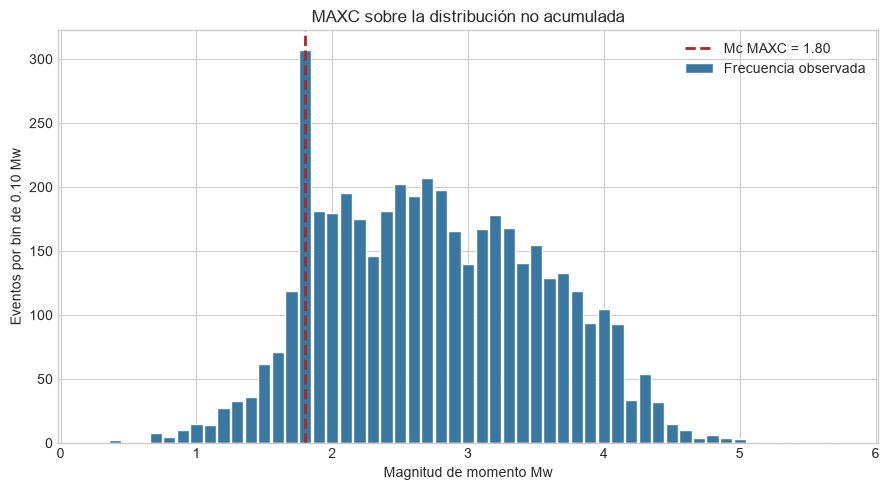

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    fmd_full["magnitude"],
    fmd_full["frequency"],
    width=BIN_WIDTH * 0.9,
    color="#3A78A1",
    edgecolor="white",
    label="Frecuencia observada",
)
ax.axvline(
    maxc_full["Mc_MAXC"],
    color="#B3261E",
    linestyle="--",
    linewidth=2,
    label=f"Mc MAXC = {maxc_full['Mc_MAXC']:.2f}",
)
ax.set(
    title="MAXC sobre la distribución no acumulada",
    xlabel="Magnitud de momento Mw",
    ylabel=f"Eventos por bin de {BIN_WIDTH:.2f} Mw",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "maxc_full.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Sensibilidad de MAXC al binning

Cambiar el ancho de bin modifica qué magnitudes quedan agrupadas y puede desplazar el máximo de frecuencia. Se repite el cálculo con tres resoluciones y se muestran todas las diferencias, sin seleccionar el resultado más conveniente.

,bin_width,Mc_MAXC,N_total,N_Mw>=Mc
0,0.100,1.800,4523,3976
1,0.200,3.400,4523,1134
2,0.250,2.500,4523,2754


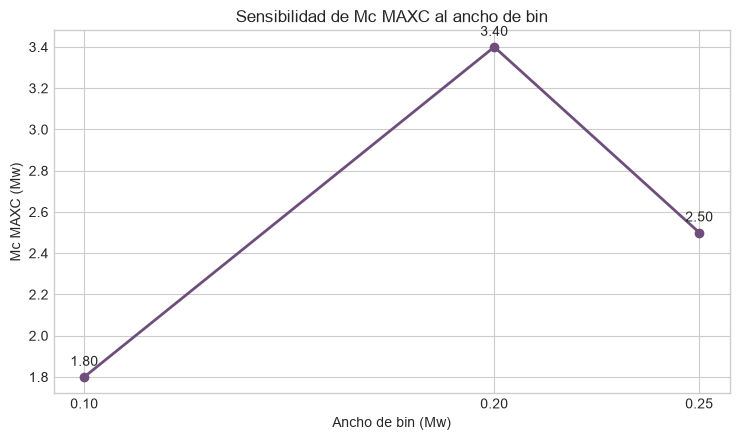

In [8]:
BIN_WIDTHS = [0.10, 0.20, 0.25]
maxc_sensitivity = pd.DataFrame(
    [
        {
            key: value
            for key, value in estimate_maxc(magnitudes, width).items()
            if key in {"bin_width", "Mc_MAXC", "N_total", "N_Mw>=Mc"}
        }
        for width in BIN_WIDTHS
    ]
)
display(maxc_sensitivity)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    maxc_sensitivity["bin_width"],
    maxc_sensitivity["Mc_MAXC"],
    marker="o",
    linewidth=2,
    color="#6F4E7C",
)
for row in maxc_sensitivity.itertuples(index=False):
    ax.annotate(
        f"{row.Mc_MAXC:.2f}",
        (row.bin_width, row.Mc_MAXC),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )
ax.set(
    title="Sensibilidad de Mc MAXC al ancho de bin",
    xlabel="Ancho de bin (Mw)",
    ylabel="Mc MAXC (Mw)",
)
ax.set_xticks(BIN_WIDTHS)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "maxc_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Mc por período temporal

Mc puede cambiar cuando cambia la red o la forma de integrar las fuentes del catálogo. Se usan bloques fijos de cinco años para hacer visible esa variación. Una estimación se etiqueta **muestra limitada** si el período tiene menos de 100 eventos en total o menos de 50 eventos con `Mw ≥ Mc`; esos límites son controles operativos explícitos, no umbrales universales de la literatura.

In [9]:
def select_period(frame, start_year, end_year):
    years = frame["time_utc"].dt.year
    return frame.loc[years.between(start_year, end_year)].copy()


period_frames = {
    label: select_period(analysis_catalog, start, end)
    for label, (start, end) in PERIODS.items()
}

period_rows = []
for label, frame in period_frames.items():
    period_magnitudes = frame["mw_reference"].dropna().to_numpy(dtype=float)
    if period_magnitudes.size == 0:
        period_rows.append(
            {
                "Periodo": label,
                "N": 0,
                "Mc_MAXC": np.nan,
                "N_Mw>=Mc": 0,
                "% conservado": np.nan,
                "calidad_muestra": "muestra limitada",
            }
        )
        continue
    result = estimate_maxc(period_magnitudes, BIN_WIDTH)
    limited = (
        result["N_total"] < MIN_TOTAL_RELIABLE
        or result["N_Mw>=Mc"] < MIN_ABOVE_MC_RELIABLE
    )
    period_rows.append(
        {
            "Periodo": label,
            "N": result["N_total"],
            "Mc_MAXC": result["Mc_MAXC"],
            "N_Mw>=Mc": result["N_Mw>=Mc"],
            "% conservado": 100 * result["N_Mw>=Mc"] / result["N_total"],
            "calidad_muestra": "muestra limitada" if limited else "muestra suficiente",
        }
    )

maxc_by_period = pd.DataFrame(period_rows)
display(maxc_by_period)

,Periodo,N,Mc_MAXC,N_Mw>=Mc,% conservado,calidad_muestra
0,2000-2004,673,3.700,206,30.609,muestra suficiente
1,2005-2009,584,3.100,406,69.521,muestra suficiente
2,2010-2014,2152,1.800,1817,84.433,muestra suficiente
3,2015-2019,704,1.800,508,72.159,muestra suficiente
4,2020-2025,410,2.800,241,58.780,muestra suficiente


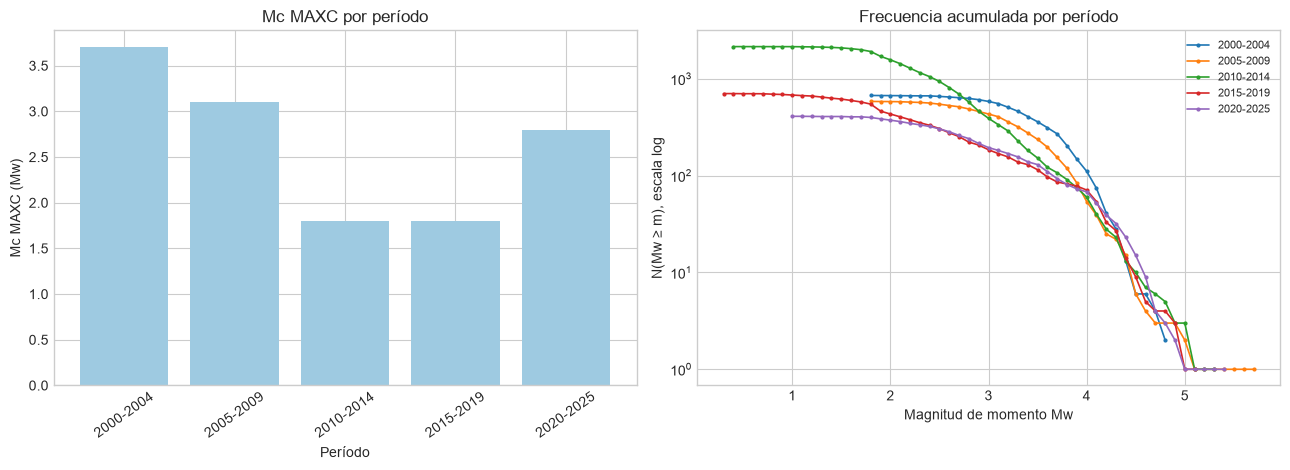

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = ["#9ECAE1" if quality == "muestra suficiente" else "#F4A261"
          for quality in maxc_by_period["calidad_muestra"]]

axes[0].bar(maxc_by_period["Periodo"], maxc_by_period["Mc_MAXC"], color=colors)
axes[0].set(
    title="Mc MAXC por período",
    xlabel="Período",
    ylabel="Mc MAXC (Mw)",
)
axes[0].tick_params(axis="x", rotation=35)

for label, frame in period_frames.items():
    values = frame["mw_reference"].dropna().to_numpy(dtype=float)
    if values.size:
        fmd = magnitude_distribution(values, BIN_WIDTH)
        mask = fmd["cumulative"] > 0
        axes[1].semilogy(
            fmd.loc[mask, "magnitude"],
            fmd.loc[mask, "cumulative"],
            marker="o",
            markersize=2,
            linewidth=1.2,
            label=label,
        )
axes[1].set(
    title="Frecuencia acumulada por período",
    xlabel="Magnitud de momento Mw",
    ylabel="N(Mw ≥ m), escala log",
)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mc_by_period.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Ajuste Gutenberg–Richter

La relación Gutenberg–Richter se expresa como

\[
\log_{10} N(M \geq m) = a - b\,m.
\]

Para cada Mc candidato se estima `b` por máxima verosimilitud con la corrección por discretización de media unidad de bin:

\[
b = \frac{\log_{10}(e)}{\overline{M} - (Mc - \Delta M/2)}.
\]

Después se obtiene `a` imponiendo que el modelo reproduzca el número de eventos en Mc. Esta formulación es la utilizada en el procedimiento GFT descrito por Wiemer y Wyss (2000) y en la revisión CORSSA de Mignan y Woessner (2012). Aquí `a` y `b` sirven para evaluar el ajuste de completitud; **no se interpretan tectónicamente**.

In [11]:
def fit_gutenberg_richter(values, mc, bin_width=0.10, min_events=20):
    # Ajusta Gutenberg–Richter sobre Mw >= Mc - ΔM/2 mediante MLE.
    values = np.asarray(values, dtype=float)
    selected = values[np.isfinite(values) & (values >= mc - bin_width / 2)]
    if selected.size < min_events:
        return None
    denominator = selected.mean() - (mc - bin_width / 2)
    if denominator <= 0:
        return None
    b_value = np.log10(np.e) / denominator
    a_value = np.log10(selected.size) + b_value * mc
    return {
        "Mc": float(mc),
        "N": int(selected.size),
        "a": float(a_value),
        "b": float(b_value),
        "selected": selected,
    }


def cumulative_from_centers(values, centers, bin_width=0.10):
    values = np.asarray(values, dtype=float)
    return np.array(
        [np.sum(values >= center - bin_width / 2) for center in centers], dtype=float
    )


gr_full = fit_gutenberg_richter(magnitudes, maxc_full["Mc_MAXC"], BIN_WIDTH)
if gr_full is None:
    raise RuntimeError("No hay eventos suficientes para el ajuste Gutenberg–Richter.")

gr_summary = pd.DataFrame(
    [{key: gr_full[key] for key in ("Mc", "N", "a", "b")}]
)
display(gr_summary)

,Mc,N,a,b
0,1.800,4119,4.304,0.383


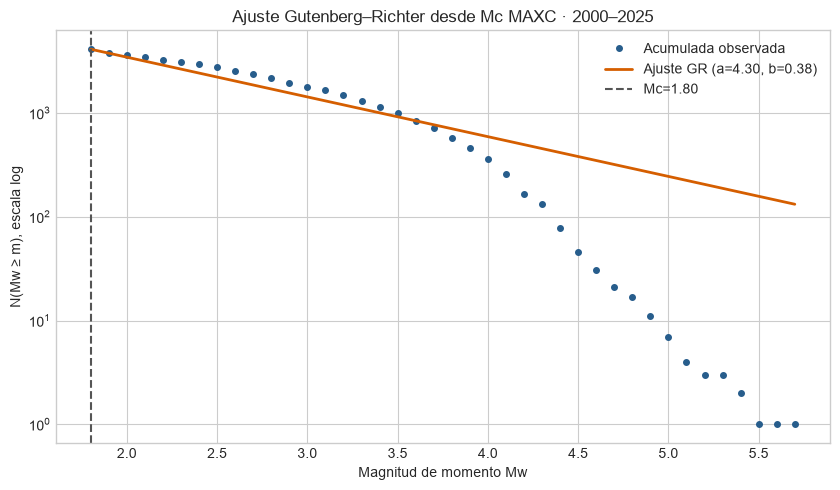

In [12]:
gr_centers = fmd_full.loc[
    fmd_full["magnitude"].ge(gr_full["Mc"]), "magnitude"
].to_numpy()
observed_gr = cumulative_from_centers(magnitudes, gr_centers, BIN_WIDTH)
expected_gr = 10 ** (gr_full["a"] - gr_full["b"] * gr_centers)
valid_gr = observed_gr > 0

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.semilogy(
    gr_centers[valid_gr],
    observed_gr[valid_gr],
    "o",
    markersize=4,
    label="Acumulada observada",
    color="#275D8C",
)
ax.semilogy(
    gr_centers,
    expected_gr,
    linewidth=2,
    label=f"Ajuste GR (a={gr_full['a']:.2f}, b={gr_full['b']:.2f})",
    color="#D55E00",
)
ax.axvline(gr_full["Mc"], linestyle="--", color="#555555", label=f"Mc={gr_full['Mc']:.2f}")
ax.set(
    title="Ajuste Gutenberg–Richter desde Mc MAXC · 2000–2025",
    xlabel="Magnitud de momento Mw",
    ylabel="N(Mw ≥ m), escala log",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gutenberg_richter_full.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Validación de Mc con Goodness-of-Fit Test (GFT)

El GFT de **Wiemer y Wyss (2000)** compara la distribución acumulada observada (`Bᵢ`) con la esperada por Gutenberg–Richter (`Sᵢ`) para cada Mc candidato:

\[
R = 100\left(1 - \frac{\sum_i |B_i-S_i|}{\sum_i B_i}\right).
\]

`R` es el porcentaje de la distribución observada explicado por el modelo según esta métrica; no es un p-valor ni un intervalo de confianza. Se exploran candidatos en pasos de 0.1 Mw y se selecciona el menor que alcanza 90% o 95%, si existe. Para evitar ajustes dominados por muy pocos datos, solo se calculan candidatos con al menos 20 eventos sobre el umbral; esta regla se informa y no reemplaza el diagnóstico de muestra limitada.

**Referencia metodológica:** Wiemer, S. & Wyss, M. (2000), *Minimum Magnitude of Completeness in Earthquake Catalogs*, BSSA 90(4), 859–869, [doi:10.1785/0119990114](https://doi.org/10.1785/0119990114). Implementación contrastada con Mignan, A. & Woessner, J. (2012), *Estimating the magnitude of completeness for earthquake catalogs*, [CORSSA](https://doi.org/10.5078/corssa-00180805).

In [13]:
def goodness_of_fit_scan(values, bin_width=0.10, min_events=20):
    # Calcula R de Wiemer–Wyss para una grilla completa de Mc candidatos.
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return pd.DataFrame(columns=["Mc_candidato", "N_eventos", "ajuste_pct", "a", "b"])

    first = np.floor(values.min() / bin_width) * bin_width
    last = np.floor(values.max() / bin_width) * bin_width
    candidates = np.round(np.arange(first, last + bin_width / 2, bin_width), 10)
    rows = []

    for mc in candidates:
        fit = fit_gutenberg_richter(values, mc, bin_width, min_events=min_events)
        if fit is None:
            continue
        centers = candidates[candidates >= mc]
        observed = cumulative_from_centers(values, centers, bin_width)
        expected = 10 ** (fit["a"] - fit["b"] * centers)
        denominator = observed.sum()
        if denominator <= 0:
            continue
        r_value = 100 * (1 - np.abs(observed - expected).sum() / denominator)
        rows.append(
            {
                "Mc_candidato": float(mc),
                "N_eventos": fit["N"],
                "ajuste_pct": float(r_value),
                "a": fit["a"],
                "b": fit["b"],
            }
        )
    return pd.DataFrame(rows)


def first_mc_at_threshold(scan, threshold):
    qualifying = scan.loc[scan["ajuste_pct"].ge(threshold)]
    return np.nan if qualifying.empty else float(qualifying.iloc[0]["Mc_candidato"])


gft_full = goodness_of_fit_scan(magnitudes, BIN_WIDTH)
mc_gft90_full = first_mc_at_threshold(gft_full, 90)
mc_gft95_full = first_mc_at_threshold(gft_full, 95)

print(f"Mc GFT90: {mc_gft90_full if np.isfinite(mc_gft90_full) else 'no alcanzado'}")
print(f"Mc GFT95: {mc_gft95_full if np.isfinite(mc_gft95_full) else 'no alcanzado'}")
display(gft_full[["Mc_candidato", "N_eventos", "ajuste_pct"]])

Mc GFT90: 3.9
Mc GFT95: 4.0


,Mc_candidato,N_eventos,ajuste_pct
0,0.300,4523,63.474
1,0.400,4523,63.950
2,0.500,4521,64.470
3,0.600,4520,65.076
4,0.700,4519,65.770
5,0.800,4511,66.476
6,0.900,4506,67.303
7,1.000,4496,68.201
8,1.100,4481,69.187
9,1.200,4467,70.355


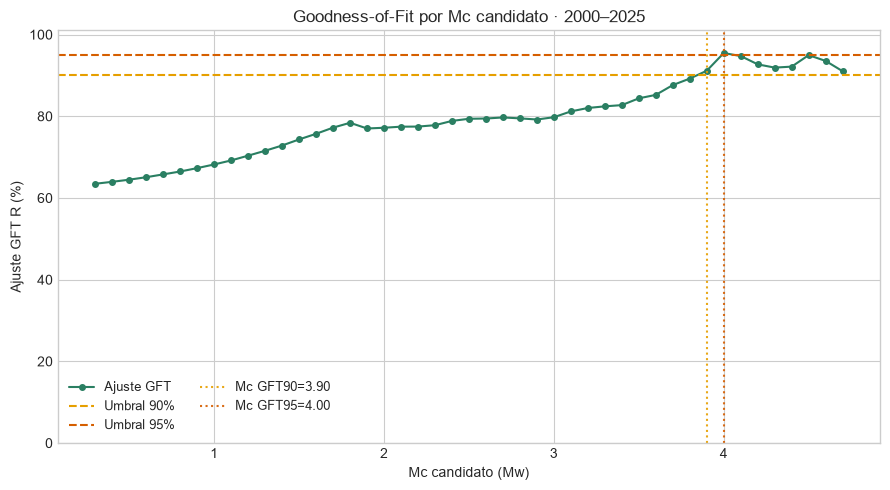

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    gft_full["Mc_candidato"],
    gft_full["ajuste_pct"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color="#2A7F62",
    label="Ajuste GFT",
)
for threshold, color in [(90, "#E69F00"), (95, "#D55E00")]:
    ax.axhline(threshold, linestyle="--", color=color, label=f"Umbral {threshold}%")
for mc, label, color in [
    (mc_gft90_full, "Mc GFT90", "#E69F00"),
    (mc_gft95_full, "Mc GFT95", "#D55E00"),
]:
    if np.isfinite(mc):
        ax.axvline(mc, linestyle=":", color=color, alpha=0.9, label=f"{label}={mc:.2f}")
ax.set(
    title="Goodness-of-Fit por Mc candidato · 2000–2025",
    xlabel="Mc candidato (Mw)",
    ylabel="Ajuste GFT R (%)",
)
ax.set_ylim(min(0, gft_full["ajuste_pct"].min() - 5), 101)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gft_full.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Comparación MAXC vs GFT

La misma rutina se aplica al catálogo completo y a cada bloque temporal. Las celdas siguientes conservan los resultados aunque los métodos discrepen. Las observaciones distinguen entre falta de umbral GFT, muestra limitada y diferencias entre estimadores.

In [15]:
def compare_mc_for_sample(label, values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {
            "Periodo": label,
            "N": 0,
            "Mc_MAXC": np.nan,
            "Mc_GFT90": np.nan,
            "Mc_GFT95": np.nan,
            "observaciones": "sin eventos",
        }, pd.DataFrame()

    maxc = estimate_maxc(values, BIN_WIDTH)
    scan = goodness_of_fit_scan(values, BIN_WIDTH)
    gft90 = first_mc_at_threshold(scan, 90)
    gft95 = first_mc_at_threshold(scan, 95)
    observations = []
    if maxc["N_total"] < MIN_TOTAL_RELIABLE or maxc["N_Mw>=Mc"] < MIN_ABOVE_MC_RELIABLE:
        observations.append("muestra limitada")
    if not np.isfinite(gft90):
        observations.append("GFT90 no alcanzado")
    if not np.isfinite(gft95):
        observations.append("GFT95 no alcanzado")
    if np.isfinite(gft90) and abs(maxc["Mc_MAXC"] - gft90) > 0.20 + 1e-9:
        observations.append("MAXC y GFT90 difieren >0.20 Mw")
    if not observations:
        observations.append("sin alertas según criterios operativos")
    return {
        "Periodo": label,
        "N": maxc["N_total"],
        "Mc_MAXC": maxc["Mc_MAXC"],
        "Mc_GFT90": gft90,
        "Mc_GFT95": gft95,
        "observaciones": "; ".join(observations),
    }, scan


comparison_rows = []
gft_scans = {}

full_row, full_scan = compare_mc_for_sample("2000-2025 completo", magnitudes)
comparison_rows.append(full_row)
gft_scans["2000-2025 completo"] = full_scan

for label, frame in period_frames.items():
    row, scan = compare_mc_for_sample(
        label, frame["mw_reference"].dropna().to_numpy(dtype=float)
    )
    comparison_rows.append(row)
    gft_scans[label] = scan

mc_comparison = pd.DataFrame(comparison_rows)
display(mc_comparison)

,Periodo,N,Mc_MAXC,Mc_GFT90,Mc_GFT95,observaciones
0,2000-2025 completo,4523,1.800,3.900,4.000,MAXC y GFT90 difieren >0.20 Mw
1,2000-2004,673,3.700,3.800,NaN,GFT95 no alcanzado
2,2005-2009,584,3.100,3.600,NaN,GFT95 no alcanzado; MAXC y GFT90 difieren >0.2...
3,2010-2014,2152,1.800,2.400,2.600,MAXC y GFT90 difieren >0.20 Mw
4,2015-2019,704,1.800,4.000,NaN,GFT95 no alcanzado; MAXC y GFT90 difieren >0.2...
5,2020-2025,410,2.800,4.300,NaN,GFT95 no alcanzado; MAXC y GFT90 difieren >0.2...


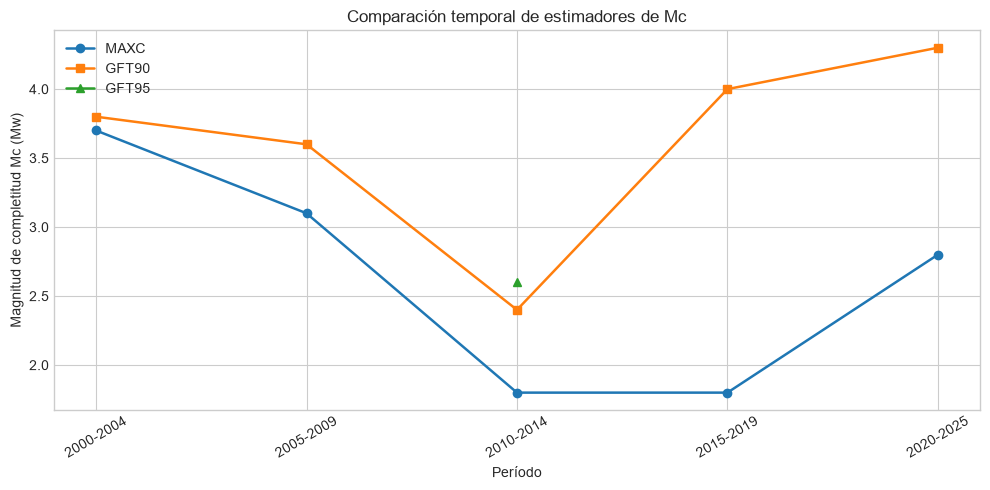

In [16]:
period_only = mc_comparison.loc[mc_comparison["Periodo"].isin(PERIODS)].copy()
x = np.arange(len(period_only))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, period_only["Mc_MAXC"], "o-", label="MAXC", linewidth=1.8)
ax.plot(x, period_only["Mc_GFT90"], "s-", label="GFT90", linewidth=1.8)
ax.plot(x, period_only["Mc_GFT95"], "^-", label="GFT95", linewidth=1.8)
ax.set_xticks(x, period_only["Periodo"], rotation=30)
ax.set(
    title="Comparación temporal de estimadores de Mc",
    xlabel="Período",
    ylabel="Magnitud de completitud Mc (Mw)",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mc_methods_by_period.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Interpretación y criterio provisional

La síntesis siguiente se genera desde las tablas calculadas para mantener la conclusión conectada con los datos. Se evalúan estabilidad temporal, disponibilidad de GFT y tamaño de muestra; ningún método se adopta automáticamente.

In [17]:
reliable_labels = maxc_by_period.loc[
    maxc_by_period["calidad_muestra"].eq("muestra suficiente"), "Periodo"
].tolist()
limited_labels = maxc_by_period.loc[
    maxc_by_period["calidad_muestra"].eq("muestra limitada"), "Periodo"
].tolist()

reliable_comparison = period_only.loc[period_only["Periodo"].isin(reliable_labels)].copy()
method_columns = ["Mc_MAXC", "Mc_GFT90", "Mc_GFT95"]
available_candidates = reliable_comparison[method_columns].stack().dropna()
temporal_spread = (
    float(available_candidates.max() - available_candidates.min())
    if not available_candidates.empty
    else np.nan
)

full_candidates = full_row
candidate_text = ", ".join(
    f"{name.replace('Mc_', '')}={full_candidates[name]:.2f} Mw"
    for name in method_columns
    if np.isfinite(full_candidates[name])
)

stable_labels = []
for row in reliable_comparison.itertuples(index=False):
    estimates = np.array([row.Mc_MAXC, row.Mc_GFT90, row.Mc_GFT95], dtype=float)
    estimates = estimates[np.isfinite(estimates)]
    if estimates.size >= 2 and estimates.max() - estimates.min() <= 0.30 + 1e-9:
        stable_labels.append(row.Periodo)

irregular_labels = period_only.loc[
    period_only["observaciones"].str.contains("difieren|no alcanzado", regex=True), "Periodo"
].tolist()

if np.isfinite(full_row["Mc_GFT90"]) and np.isfinite(full_row["Mc_GFT95"]):
    provisional_candidate_line = (
        f"- **Candidatos provisionales para evaluar:** {full_row['Mc_GFT90']:.2f} Mw (GFT90) "
        f"y {full_row['Mc_GFT95']:.2f} Mw (GFT95). MAXC={full_row['Mc_MAXC']:.2f} Mw "
        "se conserva como referencia inferior, pero no se adopta por su sensibilidad al binning."
    )
else:
    provisional_candidate_line = (
        "- **Candidatos provisionales para evaluar:** los valores disponibles en la tabla comparativa; "
        "la ausencia de uno o ambos umbrales GFT impide priorizar un único valor."
    )

interpretation_lines = [
    f"- Para el catálogo completo, los candidatos disponibles son: **{candidate_text or 'ninguno'}**.",
    f"- Períodos con muestra suficiente según los controles operativos: **{', '.join(reliable_labels) or 'ninguno'}**.",
    f"- Períodos con estimadores internamente próximos (rango ≤0.30 Mw): **{', '.join(stable_labels) or 'ninguno'}**.",
    f"- Períodos marcados como muestra limitada: **{', '.join(limited_labels) or 'ninguno'}**.",
    f"- Períodos con señales de cobertura o ajuste irregular (GFT ausente o discrepancia entre métodos): **{', '.join(irregular_labels) or 'ninguno'}**.",
    provisional_candidate_line,
]
if np.isfinite(temporal_spread):
    interpretation_lines.append(
        f"- El rango conjunto de estimaciones disponibles en períodos con muestra suficiente es **{temporal_spread:.2f} Mw**."
    )
interpretation_lines.extend(
    [
        "- La propuesta provisional es conservar el rango de candidatos mostrado, priorizando para análisis posteriores el umbral que también sea estable entre períodos y deje una cantidad adecuada de eventos.",
        "- La decisión final debe considerar conjuntamente estabilidad temporal, cantidad de eventos y posibles cambios de cobertura; estos resultados no prueban por sí solos una interpretación tectónica.",
    ]
)
display(Markdown("\n".join(interpretation_lines)))

- Para el catálogo completo, los candidatos disponibles son: **MAXC=1.80 Mw, GFT90=3.90 Mw, GFT95=4.00 Mw**.
- Períodos con muestra suficiente según los controles operativos: **2000-2004, 2005-2009, 2010-2014, 2015-2019, 2020-2025**.
- Períodos con estimadores internamente próximos (rango ≤0.30 Mw): **2000-2004**.
- Períodos marcados como muestra limitada: **ninguno**.
- Períodos con señales de cobertura o ajuste irregular (GFT ausente o discrepancia entre métodos): **2000-2004, 2005-2009, 2010-2014, 2015-2019, 2020-2025**.
- **Candidatos provisionales para evaluar:** 3.90 Mw (GFT90) y 4.00 Mw (GFT95). MAXC=1.80 Mw se conserva como referencia inferior, pero no se adopta por su sensibilidad al binning.
- El rango conjunto de estimaciones disponibles en períodos con muestra suficiente es **2.50 Mw**.
- La propuesta provisional es conservar el rango de candidatos mostrado, priorizando para análisis posteriores el umbral que también sea estable entre períodos y deje una cantidad adecuada de eventos.
- La decisión final debe considerar conjuntamente estabilidad temporal, cantidad de eventos y posibles cambios de cobertura; estos resultados no prueban por sí solos una interpretación tectónica.

## 10. Subconjunto analítico condicionado a una decisión clara

Para evitar una selección subjetiva, se considera convergencia operativa solo si: (1) MAXC, GFT90 y GFT95 existen para el catálogo completo y abarcan como máximo 0.20 Mw; (2) hay al menos tres períodos con muestra suficiente; (3) al menos 80% de ellos alcanza ambos umbrales GFT; y (4) el rango total de sus estimaciones no supera 0.30 Mw. Estos criterios son conservadores y quedan expuestos para revisión; no son una regla científica universal.

In [18]:
full_values = np.array(
    [full_row["Mc_MAXC"], full_row["Mc_GFT90"], full_row["Mc_GFT95"]], dtype=float
)
all_full_available = np.isfinite(full_values).all()
full_convergence = bool(all_full_available and np.ptp(full_values) <= 0.20 + 1e-9)

if reliable_comparison.empty:
    gft_coverage = 0.0
else:
    gft_coverage = float(
        reliable_comparison[["Mc_GFT90", "Mc_GFT95"]].notna().all(axis=1).mean()
    )

enough_periods = len(reliable_labels) >= 3
temporal_convergence = bool(np.isfinite(temporal_spread) and temporal_spread <= 0.30 + 1e-9)
decision_clear = bool(
    full_convergence and enough_periods and gft_coverage >= 0.80 and temporal_convergence
)

decision_diagnostics = pd.DataFrame(
    {
        "criterio": [
            "Tres métodos disponibles en catálogo completo",
            "Rango completo ≤ 0.20 Mw",
            "Al menos 3 períodos con muestra suficiente",
            "Cobertura GFT90+GFT95 ≥ 80%",
            "Rango temporal conjunto ≤ 0.30 Mw",
        ],
        "resultado": [
            all_full_available,
            full_convergence,
            enough_periods,
            gft_coverage >= 0.80,
            temporal_convergence,
        ],
        "detalle": [
            f"valores={full_values.tolist()}",
            f"rango={np.ptp(full_values) if all_full_available else np.nan:.2f} Mw",
            f"n={len(reliable_labels)}",
            f"cobertura={100*gft_coverage:.1f}%",
            f"rango={temporal_spread:.2f} Mw" if np.isfinite(temporal_spread) else "sin estimación",
        ],
    }
)
display(decision_diagnostics)

if decision_clear:
    adopted_mc = float(np.max(full_values))  # opción conservadora dentro de estimadores convergentes
    adopted_period = (2000, 2025)
    analytical_subset = analysis_catalog.loc[
        analysis_catalog["time_utc"].dt.year.between(*adopted_period)
        & analysis_catalog["mw_reference"].ge(adopted_mc)
    ].copy()
    display(
        Markdown(
            f"**Decisión operativa clara:** Mc={adopted_mc:.2f} Mw para "
            f"{adopted_period[0]}–{adopted_period[1]}. "
            f"El DataFrame `analytical_subset` contiene **{len(analytical_subset):,} eventos**. "
            "No se exporta ni se sobrescribe el catálogo v1.1."
        )
    )
else:
    adopted_mc = None
    adopted_period = None
    analytical_subset = None
    display(
        Markdown(
            "**La convergencia no satisface todos los criterios conservadores.** "
            "No se crea ni exporta todavía un subconjunto definitivo; se mantienen los candidatos "
            "en `mc_comparison` para decidir después de revisar estabilidad temporal y tamaño de muestra."
        )
    )

,criterio,resultado,detalle
0,Tres métodos disponibles en catálogo completo,True,"valores=[1.8, 3.9, 4.0]"
1,Rango completo ≤ 0.20 Mw,False,rango=2.20 Mw
2,Al menos 3 períodos con muestra suficiente,True,n=5
3,Cobertura GFT90+GFT95 ≥ 80%,False,cobertura=20.0%
4,Rango temporal conjunto ≤ 0.30 Mw,False,rango=2.50 Mw


**La convergencia no satisface todos los criterios conservadores.** No se crea ni exporta todavía un subconjunto definitivo; se mantienen los candidatos en `mc_comparison` para decidir después de revisar estabilidad temporal y tamaño de muestra.

## 11. Salidas y control de reproducibilidad

Se comprueba que las cinco figuras requeridas existen y tienen contenido. El catálogo de entrada solo fue leído; ninguna celda escribe sobre `data/processed/`.

In [19]:
expected_figures = [
    "frequency_magnitude_full.png",
    "maxc_full.png",
    "maxc_sensitivity.png",
    "mc_by_period.png",
    "mc_methods_by_period.png",
    "gutenberg_richter_full.png",
    "gft_full.png",
]
output_check = pd.DataFrame(
    [
        {
            "archivo": name,
            "existe": (OUTPUT_DIR / name).exists(),
            "tamaño_kb": (OUTPUT_DIR / name).stat().st_size / 1024
            if (OUTPUT_DIR / name).exists()
            else np.nan,
        }
        for name in expected_figures
    ]
)
display(output_check)

if not output_check["existe"].all():
    raise RuntimeError("Falta al menos una figura requerida.")

print("Notebook ejecutado hasta el final sin modificar el CSV de entrada.")

,archivo,existe,tamaño_kb
0,frequency_magnitude_full.png,True,96.774
1,maxc_full.png,True,47.555
2,maxc_sensitivity.png,True,63.782
3,mc_by_period.png,True,134.834
4,mc_methods_by_period.png,True,102.990
5,gutenberg_richter_full.png,True,77.170
6,gft_full.png,True,70.471


Notebook ejecutado hasta el final sin modificar el CSV de entrada.
